# Ringkasan Dataset

Dataset ini berisi 254.736 baris data kualitas udara per jam dari 29 kota besar di dunia (termasuk Lahore, Delhi, Beijing, Jakarta, dll.) selama periode Mei 2025 – Mei 2026.

Kolom yang tersedia:

Timestamp — waktu per jam

City, Latitude, Longitude — identitas lokasi

PM2_5_ug_m3, PM10_ug_m3 — partikel polutan utama

Carbon_Monoxide_ug_m3, Nitrogen_Dioxide_ug_m3, Ozone_ug_m3, Dust_ug_m3 — gas polutan

UV_Index — indeks UV

European_AQI — indeks kualitas udara

Hazardous_Event — apakah terjadi event berbahaya (0/1)



# Tujuan

yaitu Memprediksi Regresi — "Berapa nilai PM2.5 jam berikutnya?"
Memprediksi angka konsentrasi polutan di masa depan.

PM2.5 adalah partikel udara yang sangat kecil berukuran 2.5 mikrometer atau lebih kecil.

# 1.Import And Read Dataset

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
df = pd.read_csv('global_urban_smog_pm25_hourly.csv')
df.head()

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
0,2025-05-22T00:00,Lahore,31.5204,74.3587,186.7,74.3,926,22.9,94,197,0.0,76,0
1,2025-05-22T01:00,Lahore,31.5204,74.3587,286.8,96.4,736,18.1,103,356,0.0,77,0
2,2025-05-22T02:00,Lahore,31.5204,74.3587,380.0,122.0,599,14.1,110,506,0.0,78,0
3,2025-05-22T03:00,Lahore,31.5204,74.3587,486.2,149.9,548,11.7,114,640,0.0,80,0
4,2025-05-22T04:00,Lahore,31.5204,74.3587,581.1,172.8,550,10.1,118,765,0.0,85,0


In [47]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(['City','Timestamp']).reset_index(drop=True)

In [48]:
df['jam'] = df['Timestamp'].dt.hour
df['hari'] = df['Timestamp'].dt.dayofweek
df['bulan'] = df['Timestamp'].dt.month

In [49]:
print(len(df))

254736


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254736 entries, 0 to 254735
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Timestamp               254736 non-null  datetime64[ns]
 1   City                    254736 non-null  object        
 2   Latitude                254736 non-null  float64       
 3   Longitude               254736 non-null  float64       
 4   PM10_ug_m3              254710 non-null  float64       
 5   PM2_5_ug_m3             254736 non-null  float64       
 6   Carbon_Monoxide_ug_m3   254736 non-null  int64         
 7   Nitrogen_Dioxide_ug_m3  254736 non-null  float64       
 8   Ozone_ug_m3             254736 non-null  int64         
 9   Dust_ug_m3              254736 non-null  int64         
 10  UV_Index                254736 non-null  float64       
 11  European_AQI            254736 non-null  int64         
 12  Hazardous_Event         254736

# 2.Data CLeaning

In [51]:
print(df.isnull().sum()[df.isnull().sum()>0])

PM10_ug_m3    26
dtype: int64


In [52]:
print(len(df))

254736


In [53]:
df['PM10_ug_m3'] = df.groupby('City')['PM10_ug_m3'].transform(lambda x: x.fillna(x.median()))


In [54]:
print(len(df))

254736


In [55]:
print(df.isnull().sum())

Timestamp                 0
City                      0
Latitude                  0
Longitude                 0
PM10_ug_m3                0
PM2_5_ug_m3               0
Carbon_Monoxide_ug_m3     0
Nitrogen_Dioxide_ug_m3    0
Ozone_ug_m3               0
Dust_ug_m3                0
UV_Index                  0
European_AQI              0
Hazardous_Event           0
jam                       0
hari                      0
bulan                     0
dtype: int64


In [56]:
df.duplicated().sum()

np.int64(0)

# 3.EDA

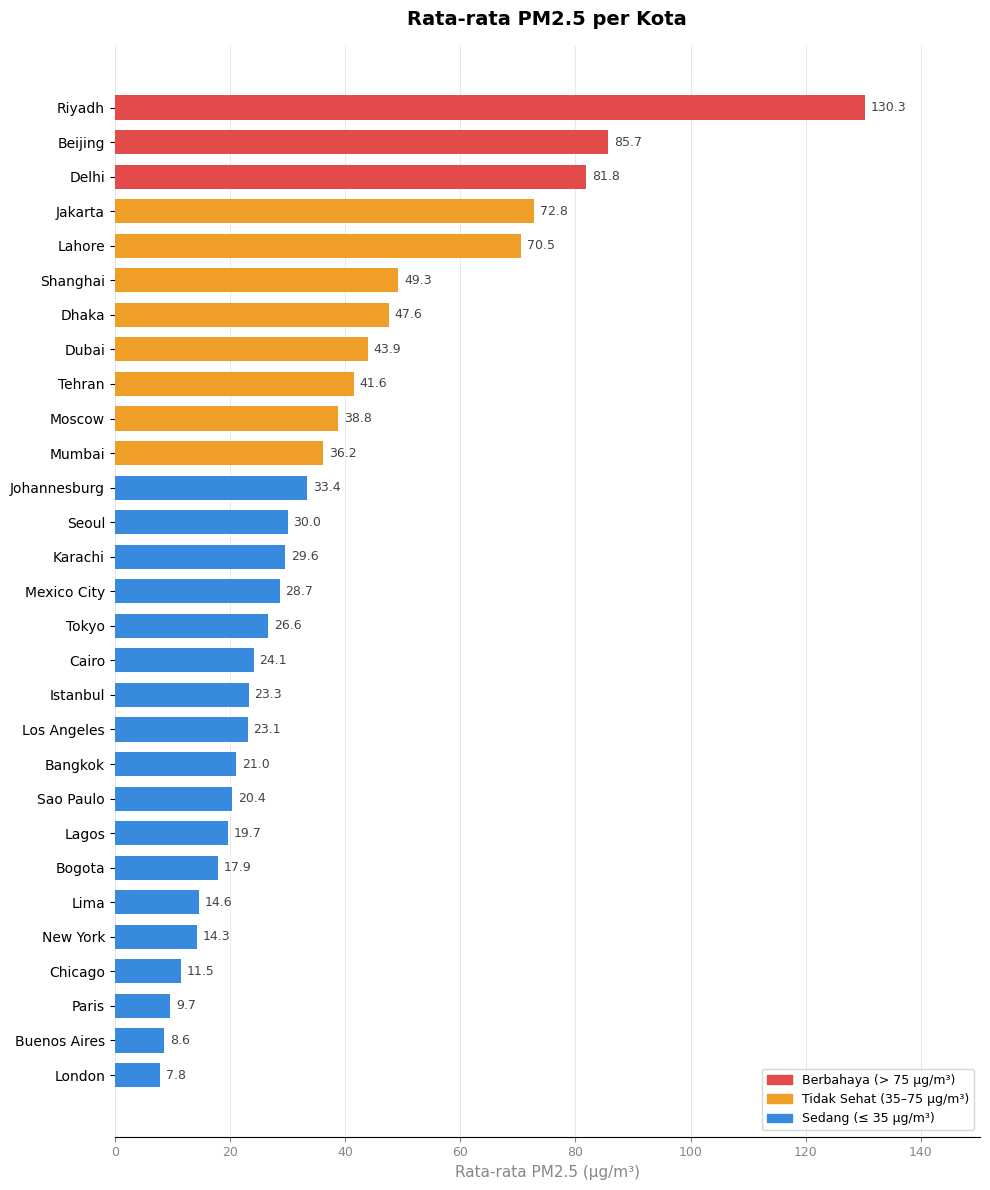

In [57]:
polusi_kota = df.groupby('City')['PM2_5_ug_m3'].mean().sort_values(ascending=False)

def tentukan_warna(nilai):
    if nilai > 75:
        return '#E24B4A'   # Merah — Berbahaya
    elif nilai > 35:
        return '#EF9F27'   # Kuning — Tidak Sehat
    else:
        return '#378ADD'   # Biru — Sedang

warna = [tentukan_warna(v) for v in polusi_kota.values]

# Buat visualisasi
fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(
    polusi_kota.index,
    polusi_kota.values,
    color=warna,
    edgecolor='none',
    height=0.7
)

# Tambahkan label nilai di setiap bar
for bar, nilai in zip(bars, polusi_kota.values):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{nilai:.1f}',
        va='center',
        ha='left',
        fontsize=9,
        color='#444441'
    )

# Styling
ax.set_xlabel('Rata-rata PM2.5 (µg/m³)', fontsize=11, color='#888780')
ax.set_title('Rata-rata PM2.5 per Kota', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, polusi_kota.max() + 20)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9, colors='#888780')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, color='#e0e0e0', linewidth=0.5)
ax.set_axisbelow(True)

# Legend
legend_items = [
    mpatches.Patch(color='#E24B4A', label='Berbahaya (> 75 µg/m³)'),
    mpatches.Patch(color='#EF9F27', label='Tidak Sehat (35–75 µg/m³)'),
    mpatches.Patch(color='#378ADD', label='Sedang (≤ 35 µg/m³)')
]
ax.legend(
    handles=legend_items,
    loc='lower right',
    fontsize=9,
    framealpha=0.8
)

plt.tight_layout()
plt.savefig('visualisasi_polusi_kota.png', dpi=150, bbox_inches='tight')
plt.show()

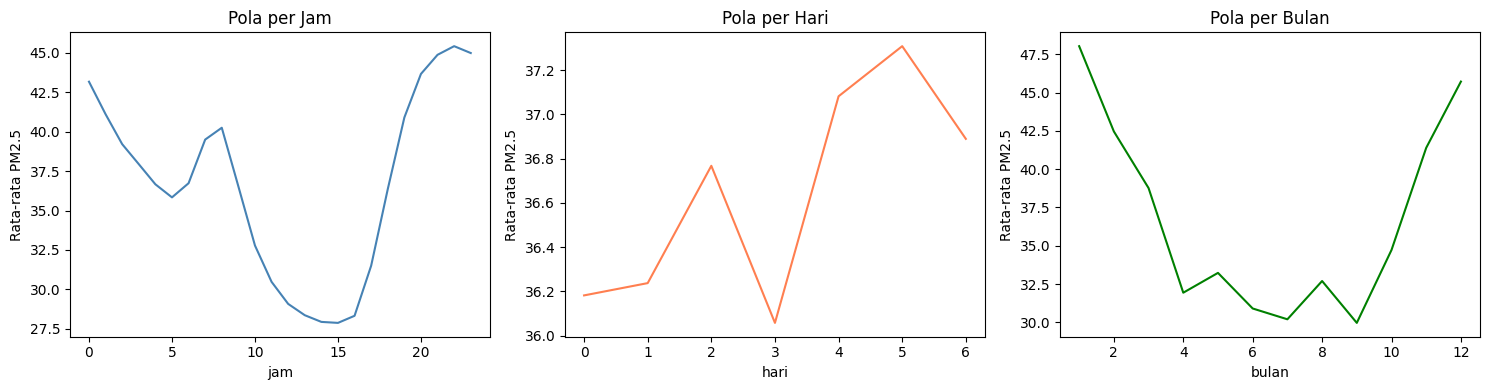

In [58]:
# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.groupby('jam')['PM2_5_ug_m3'].mean().plot(ax=axes[0], title='Pola per Jam', color='steelblue')
df.groupby('hari')['PM2_5_ug_m3'].mean().plot(ax=axes[1], title='Pola per Hari', color='coral')
df.groupby('bulan')['PM2_5_ug_m3'].mean().plot(ax=axes[2], title='Pola per Bulan', color='green')
for ax in axes:
    ax.set_ylabel('Rata-rata PM2.5')
plt.tight_layout()

# 4.Feature Engineering

In [59]:
df['is_weekend'] = (df['hari']>=5).astype(int)
df['is_workhour'] = (df['jam'].between(7,18)).astype(int)
print("Fitur Hari kerja dan jam Kerja telah Ditambahkan")

Fitur Hari kerja dan jam Kerja telah Ditambahkan


In [60]:
df['pm25_lag1'] = df.groupby('City')['PM2_5_ug_m3'].shift(1) # 1 jam lalu
df['pm25_lag3'] = df.groupby('City')['PM2_5_ug_m3'].shift(3) # 3 jam lalu
df['pm25_lag24'] = df.groupby('City')['PM2_5_ug_m3'].shift(24) # 24 jam lalu

In [61]:
print(len(df))

254736


Rolling mean 6 jam

Membuat fitur baru yang berisi rata-rata PM2.5 dari 6 jam terakhir untuk setiap kota. Tujuannya adalah menangkap tren jangka pendek — apakah polusi sedang naik atau turun dalam beberapa jam terakhir.

In [62]:
from pandas.core import window
df['pm25_rolling6'] = df.groupby('City')['PM2_5_ug_m3'].transform(lambda x:x.rolling(window=6,min_periods=1).mean())

In [63]:
df = pd.get_dummies(df,columns=['City'],prefix='city')
print("One hot encoding selesai")

One hot encoding selesai


In [64]:
print(len(df))

254736


In [65]:
df

,Timestamp,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,...,city_Moscow,city_Mumbai,city_New York,city_Paris,city_Riyadh,city_Sao Paulo,city_Seoul,city_Shanghai,city_Tehran,city_Tokyo
0,2025-05-22 00:00:00,13.7563,100.5018,16.7,16.2,942,15.0,64,0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2025-05-22 01:00:00,13.7563,100.5018,15.8,15.3,823,12.0,64,0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2025-05-22 02:00:00,13.7563,100.5018,15.1,14.8,630,10.7,63,0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2025-05-22 03:00:00,13.7563,100.5018,15.8,15.4,432,10.9,62,0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2025-05-22 04:00:00,13.7563,100.5018,16.9,16.6,385,12.9,60,0,0.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254731,2026-05-22 19:00:00,35.6895,139.6917,13.1,11.1,221,18.4,67,2,0.0,...,False,False,False,False,False,False,False,False,False,True
254732,2026-05-22 20:00:00,35.6895,139.6917,12.8,11.0,208,17.0,69,1,0.0,...,False,False,False,False,False,False,False,False,False,True
254733,2026-05-22 21:00:00,35.6895,139.6917,12.2,10.6,196,16.0,70,1,0.0,...,False,False,False,False,False,False,False,False,False,True
254734,2026-05-22 22:00:00,35.6895,139.6917,11.6,10.0,191,15.8,69,1,0.0,...,False,False,False,False,False,False,False,False,False,True


In [66]:
df.isnull().sum()

,0
Timestamp,0
Latitude,0
Longitude,0
PM10_ug_m3,0
PM2_5_ug_m3,0
Carbon_Monoxide_ug_m3,0
Nitrogen_Dioxide_ug_m3,0
Ozone_ug_m3,0
Dust_ug_m3,0
UV_Index,0


In [67]:
print(len(df))

254736


In [68]:
df = df.dropna()
print(f'shape setelah feature engineering {df.shape}')

shape setelah feature engineering (254040, 50)


In [69]:
print(len(df))

254040


In [70]:
batas_split = pd.Timestamp('2026-04-01')

In [71]:
train = df[df['Timestamp'] < batas_split]
test = df[df['Timestamp'] >= batas_split]

In [72]:
train.shape

(217848, 50)

In [73]:
test.shape

(36192, 50)

In [74]:
column_drop = ['Timestamp','Latitude','Longitude','PM2_5_ug_m3','Hazardous_Event']

In [75]:
fitur = [col for col in df.columns if col not in column_drop]

In [76]:
fitur

['PM10_ug_m3',
 'Carbon_Monoxide_ug_m3',
 'Nitrogen_Dioxide_ug_m3',
 'Ozone_ug_m3',
 'Dust_ug_m3',
 'UV_Index',
 'European_AQI',
 'jam',
 'hari',
 'bulan',
 'is_weekend',
 'is_workhour',
 'pm25_lag1',
 'pm25_lag3',
 'pm25_lag24',
 'pm25_rolling6',
 'city_Bangkok',
 'city_Beijing',
 'city_Bogota',
 'city_Buenos Aires',
 'city_Cairo',
 'city_Chicago',
 'city_Delhi',
 'city_Dhaka',
 'city_Dubai',
 'city_Istanbul',
 'city_Jakarta',
 'city_Johannesburg',
 'city_Karachi',
 'city_Lagos',
 'city_Lahore',
 'city_Lima',
 'city_London',
 'city_Los Angeles',
 'city_Mexico City',
 'city_Moscow',
 'city_Mumbai',
 'city_New York',
 'city_Paris',
 'city_Riyadh',
 'city_Sao Paulo',
 'city_Seoul',
 'city_Shanghai',
 'city_Tehran',
 'city_Tokyo']

In [77]:
X_train = train[fitur]
y_train = train['PM2_5_ug_m3']
X_test = test[fitur]
y_test = test['PM2_5_ug_m3']
print(f'Jumlah fitur yang digunakan {len(fitur)}')

Jumlah fitur yang digunakan 45


# 5.Pemodelan

In [78]:
df.shape

(254040, 50)

In [79]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)
print("Model telah dilatih")

Model telah dilatih


In [80]:
y_pred = model.predict(X_test)
print("model berhasil diprediksi")

model berhasil diprediksi


# 6.Evalusasi Model

In [81]:
mae = mean_squared_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)

print(f"\nMAE  (Mean Absolute Error) : {mae:.2f}")
print(f"\nMSE  (Mean Squared Error) : {mae:.2f}")
print(f"\nRMSE (Root Mean Sq. Error) : {rmse:.2f}")
print(f"\nR²   (R-squared)           : {r2:.4f}")
print("\nCara baca:")
print(f"   → Rata-rata prediksi meleset ±{mae:.1f} µg/m³ dari nilai asli")
print(f"   → Model menjelaskan {r2*100:.1f}% variasi data")


MAE  (Mean Absolute Error) : 32.15

MSE  (Mean Squared Error) : 32.15

RMSE (Root Mean Sq. Error) : 5.67

R²   (R-squared)           : 0.9768

Cara baca:
   → Rata-rata prediksi meleset ±32.2 µg/m³ dari nilai asli
   → Model menjelaskan 97.7% variasi data


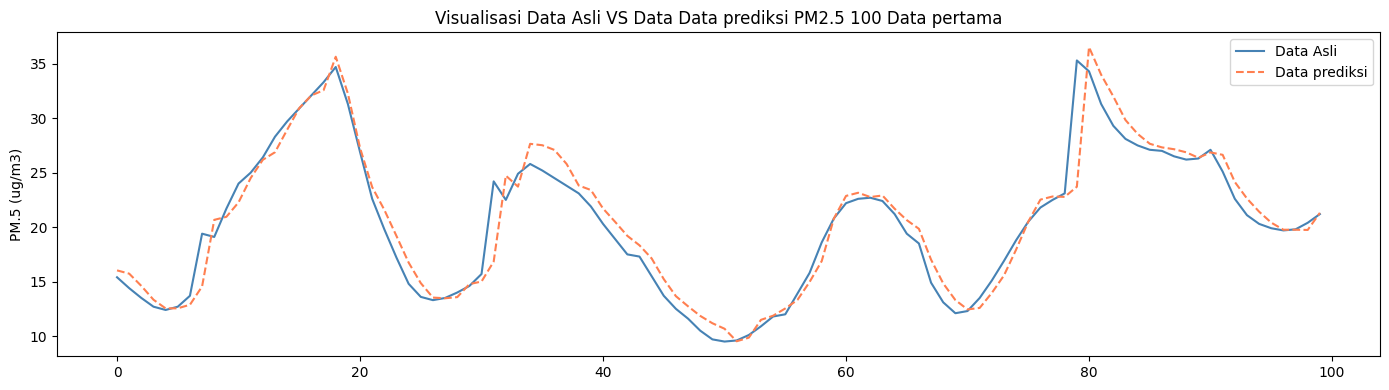

In [82]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:100],label="Data Asli",color='steelblue')
plt.plot(y_pred[:100],label='Data prediksi',color='coral',linestyle='--')
plt.title("Visualisasi Data Asli VS Data Data prediksi PM2.5 100 Data pertama")
plt.ylabel('PM.5 (ug/m3)')
plt.legend()
plt.tight_layout()

In [83]:
df_perbandingan = pd.DataFrame({
    'Data Asli' : y_test.values,
    'Data Prediksi' : y_pred,
    'Selisih ' : (y_test.values - y_pred).round(2),
    'Selisih %' : (abs(y_test.values - y_pred) / y_test.values * 100).round(2)
})

df_perbandingan.head(10)



/tmp/ipykernel_903/4240722884.py:5: RuntimeWarning: divide by zero encountered in divide
  'Selisih %' : (abs(y_test.values - y_pred) / y_test.values * 100).round(2)


,Data Asli,Data Prediksi,Selisih,Selisih %
0,15.4,16.032086,-0.63,4.10
1,14.4,15.731957,-1.33,9.25
2,13.5,14.604799,-1.10,8.18
3,12.7,13.338546,-0.64,5.03
4,12.4,12.542727,-0.14,1.15
5,12.7,12.552602,0.15,1.16
6,13.7,12.877213,0.82,6.01
7,19.4,14.558040,4.84,24.96
8,19.1,20.668559,-1.57,8.21
9,21.7,20.948928,0.75,3.46


In [84]:
print(f'{df_perbandingan['Selisih %'].mean():.2f}%')

inf%


In [85]:
range_data = y_test.max() - y_test.min()
print(f'range datanya adalah {range_data}')

range datanya adalah 588.6


# 7.Importance Fitur

In [87]:
#mencari fitur mana yang paling berpengaruh
importance_fitur = pd.Series(model.feature_importances_,index=fitur).sort_values(ascending=False)
print("Fitur Fitur Yang paling berpengaruh")
print(importance_fitur.head(10).round(4))

Fitur Fitur Yang paling berpengaruh
pm25_lag1                 0.9537
PM10_ug_m3                0.0357
Dust_ug_m3                0.0053
Carbon_Monoxide_ug_m3     0.0015
pm25_lag3                 0.0010
pm25_rolling6             0.0006
city_Moscow               0.0006
Nitrogen_Dioxide_ug_m3    0.0005
European_AQI              0.0002
city_Istanbul             0.0002
dtype: float64


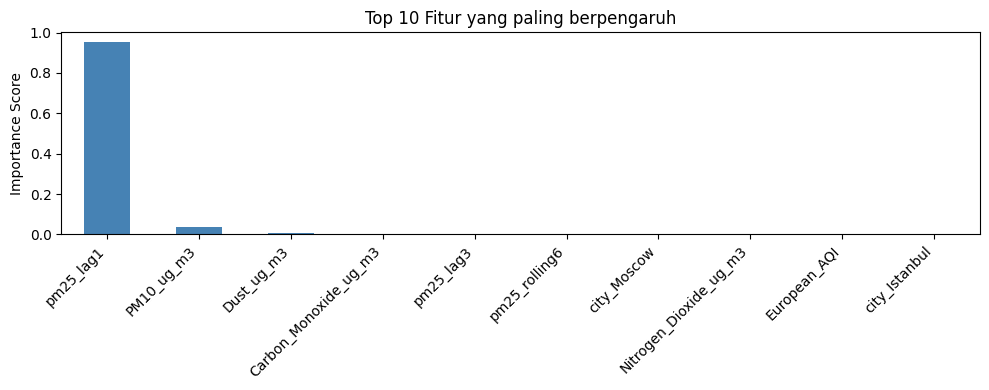

In [88]:
#membuat fitur paling berpengaruh dalam visualisasi
plt.figure(figsize=(10,4))
importance_fitur.head(10).plot(kind='bar',color='steelblue')
plt.title("Top 10 Fitur yang paling berpengaruh")
plt.ylabel("Importance Score")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [89]:
#mencari rata rata error perkota
city_cols = [col for col in df.columns if col.startswith('city_')]
test_dengan_pred = test.copy()
test_dengan_pred['prediksi'] = y_pred
test_dengan_pred['error']    = abs(test_dengan_pred['PM2_5_ug_m3'] - y_pred)

print("\n[7.3] Rata-rata error per kota (MAE):")
for city_col in city_cols:
    kota = city_col.replace('city_', '')
    subset = test_dengan_pred[test_dengan_pred[city_col] == 1]
    if len(subset) > 0:
        mae_kota = subset['error'].mean()
        print(f"   {kota:20s}: {mae_kota:.2f} µg/m³")


[7.3] Rata-rata error per kota (MAE):
   Bangkok             : 1.06 µg/m³
   Beijing             : 3.35 µg/m³
   Bogota              : 0.97 µg/m³
   Buenos Aires        : 0.52 µg/m³
   Cairo               : 2.06 µg/m³
   Chicago             : 0.52 µg/m³
   Delhi               : 7.45 µg/m³
   Dhaka               : 2.11 µg/m³
   Dubai               : 2.96 µg/m³
   Istanbul            : 2.32 µg/m³
   Jakarta             : 1.81 µg/m³
   Johannesburg        : 1.30 µg/m³
   Karachi             : 1.69 µg/m³
   Lagos               : 1.91 µg/m³
   Lahore              : 2.74 µg/m³
   Lima                : 0.95 µg/m³
   London              : 0.85 µg/m³
   Los Angeles         : 1.11 µg/m³
   Mexico City         : 1.07 µg/m³
   Moscow              : 2.95 µg/m³
   Mumbai              : 1.63 µg/m³
   New York            : 0.64 µg/m³
   Paris               : 1.01 µg/m³
   Riyadh              : 14.23 µg/m³
   Sao Paulo           : 0.85 µg/m³
   Seoul               : 1.66 µg/m³
   Shanghai            :